In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from pathlib import Path
import pandas as pd

In [51]:
import sys

# appending a path
sys.path.append('/home/pkaczyns/Code/cell-track-analysis/src')
from fixed_image_utils import read_data
from utils import extract_wells_info

In [41]:
path = "/mnt/data/2024-10-29-zkorwek/IF"#"/mnt/data/2025-05-15-wprus/fixed"


In [3]:

extract_wells_info('/mnt/data/2025-02-08-namirine-TBA/fixed')

,,,well,Virus,CellType1,CellType2,experiment
0,3,2,0302,mock,A549 WT H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
1,3,3,0303,RSV 0.1 NB6,A549 WT H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
2,3,4,0304,RSV 0.1 NB6,A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
3,3,6,0306,mock,A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
4,4,5,0405,mock,A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
5,4,7,0407,RSV 0.1 NB6,A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
6,4,9,0409,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
7,5,8,0508,RSV 0.1 NB6,A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed


In [2]:

df = read_data(['/mnt/data/2025-02-08-namirine-TBA/fixed'], use_mock=True)#, col='rsv_intensity_mean')

Read:  /mnt/data/2025-02-08-namirine-TBA/fixed


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 2 is required by GaussianMixture.

In [18]:
from pathlib import Path
folder_paths = [
    '/mnt/data/2025-01-15-wprus-TBA/IF',
    '/mnt/data/2025-01-28-namirine-TBA/IF',
    '/mnt/data/2025-02-08-namirine-TBA/fixed',
]

In [26]:
folder_paths = [
    '/mnt/data/2024-10-08-zkorwek--fixed',
    '/mnt/data/2024-11-15-zkorwek--fixed',
    '/mnt/data/2024-11-26-zkorwek--live/IF',
]

In [63]:
folder_paths = ['/mnt/data/2026-03-25-zkorwek/IF']

In [64]:
reps = []
for path in folder_paths:
    exp_nuclei = []
    for well in Path(path).glob('./*-ST/'):
        nuc_quant = pd.read_csv(well/'Img_t0000-nuc_quant.csv')
        img_quant = pd.read_csv(well/'Img_t0000-img_quant.csv')

        #nuc_quant = nuc_quant.merge(img_quant, how="left", suffixes=("", "_img"))
        for col_name in img_quant.columns:
            nuc_quant[col_name + "_img"] = img_quant.loc[0, col_name]
        nuc_quant["experiment"] = path.split("/")[-1]
        nuc_quant["well"] = re.search(r'(\d+)-ST', str(well)).group(1)
        exp_nuclei.append(nuc_quant)

    exp_nuclei = pd.concat(exp_nuclei)
    info = extract_wells_info(path)

    exp = exp_nuclei.merge(info, on=['well']).rename({"iav_intensity_mean": "virus_intensity_mean", "rsv_intensity_mean": "virus_intensity_mean"}, axis=1)
    reps.append(exp)

In [60]:
reps[0]

,nucleus_id,area,area_masked,eccentricity,is_toggled,center_x,center_y,virus_intensity_min,virus_intensity_max,virus_intensity_median,...,dpc_intensity_inertia_img,dpc_intensity_sum_img,experiment_x,well,,,Compound,Cell Type,compound 2,experiment_y
0,1,224.5,0.0,0.632,0,4032.42,7385.52,29,42,35,...,4.83520,967144276,IF,0203,2,3,mock,A549WT-H2B,mock,/mnt/data/2026-03-17-zkorwek/IF
1,2,208.0,0.0,0.369,0,4308.92,7384.28,28,38,34,...,4.83520,967144276,IF,0203,2,3,mock,A549WT-H2B,mock,/mnt/data/2026-03-17-zkorwek/IF
2,3,149.5,0.0,0.223,0,6560.56,7383.84,34,45,39,...,4.83520,967144276,IF,0203,2,3,mock,A549WT-H2B,mock,/mnt/data/2026-03-17-zkorwek/IF
3,4,188.5,0.0,0.258,0,5481.44,7383.97,32,43,37,...,4.83520,967144276,IF,0203,2,3,mock,A549WT-H2B,mock,/mnt/data/2026-03-17-zkorwek/IF
4,5,225.0,0.0,0.412,0,4968.85,7383.97,29,42,35,...,4.83520,967144276,IF,0203,2,3,mock,A549WT-H2B,mock,/mnt/data/2026-03-17-zkorwek/IF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333990,22141,569.0,0.0,0.108,0,3694.36,26.53,29,40,34,...,6.16506,805342572,IF,0610,6,10,mock,A549 IFNLRKO-H2B,IFN b 1000U/ml,/mnt/data/2026-03-17-zkorwek/IF
333991,22142,888.5,0.0,0.414,0,6259.25,27.65,27,43,35,...,6.16506,805342572,IF,0610,6,10,mock,A549 IFNLRKO-H2B,IFN b 1000U/ml,/mnt/data/2026-03-17-zkorwek/IF
333992,22143,553.0,0.0,0.192,0,4154.12,40.85,28,39,33,...,6.16506,805342572,IF,0610,6,10,mock,A549 IFNLRKO-H2B,IFN b 1000U/ml,/mnt/data/2026-03-17-zkorwek/IF
333993,22144,686.0,0.0,0.306,0,3376.81,9.94,31,46,37,...,6.16506,805342572,IF,0610,6,10,mock,A549 IFNLRKO-H2B,IFN b 1000U/ml,/mnt/data/2026-03-17-zkorwek/IF


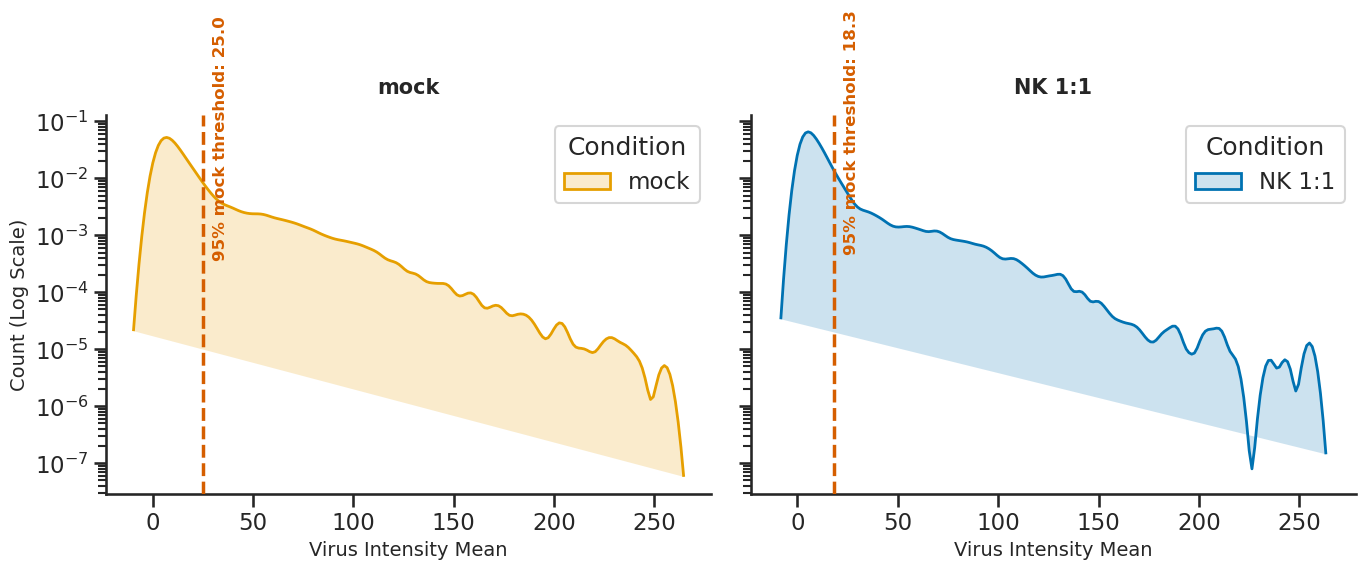

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, aesthetic theme
sns.set_theme(style="ticks", context="talk")
# Use distinct, colorblind-friendly colors (e.g., Orange for just IAV, Blue for NK+IAV)
palette = {"mock": "#E69F00", "NK 1:1": "#0072B2"} 
df = reps[0]
# 2. Identify the cell lines for the two subplots
cell_lines = df['CellType2'].unique()

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, len(cell_lines), figsize=(14, 6), sharey=True, sharex=True)

# Ensure axes is iterable even if there's only 1 cell line by chance
if not hasattr(axes, '__iter__'): axes = [axes]

for i, cell_line in enumerate(cell_lines):
    ax = axes[i]
    
    # Isolate data for this specific subplot (cell line)
    df_cell = df[df['CellType2'] == cell_line]
    
    # 3. Calculate 95th percentile threshold using wells WITHOUT IAV
    # (Assuming 'Virus' == 'mock' means no IAV)
    uninfected_mask = df_cell['Virus'].str.contains('mock', case=False, na=False)
    threshold = df_cell[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
    
    # 4. Filter to keep only the IAV-infected wells for plotting
    infected_df = df_cell[~uninfected_mask]
    
    # 5. Plot the step histogram
    sns.kdeplot(
        data=infected_df,
        x='virus_intensity_mean',
        hue='CellType2',        # This separates 'mock' (just IAV) vs 'NK 1:1' (NK+IAV)
        #element='step',         # 'step' draws outlines instead of full bars -> MUCH cleaner
        fill=True,              # Light fill under the curve
        alpha=0.2,              # Transparency
        linewidth=2,            # Thicker lines for visibility
        palette=palette,
        log_scale=(False, True),# Keeps your Y-axis log scale
        #bins=60,                # Adjust this if you want smoother or finer bins
        ax=ax,
common_norm=False)
    
    # 6. Draw the Threshold line
    ax.axvline(threshold, color='#D55E00', linestyle='--', linewidth=2.5, zorder=5)
    
    # Add a text label for the threshold line
    ymin, ymax = ax.get_ylim()
    ax.text(threshold + 5, ymax * 0.5, f'95% mock threshold: {threshold:.1f}', 
            color='#D55E00', rotation=90, verticalalignment='center', fontsize=12, fontweight='bold')

    # 7. Formatting and Titles
    ax.set_title(cell_line, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Virus Intensity Mean', fontsize=14)
    if i == 0:
        ax.set_ylabel('Count (Log Scale)', fontsize=14)
    else:
        ax.set_ylabel('')
        
    # Clean up the legend title generated by seaborn
    if ax.get_legend():
        ax.get_legend().set_title("Condition")

# Remove top and right borders for a modern look
sns.despine()
plt.tight_layout()
plt.show()

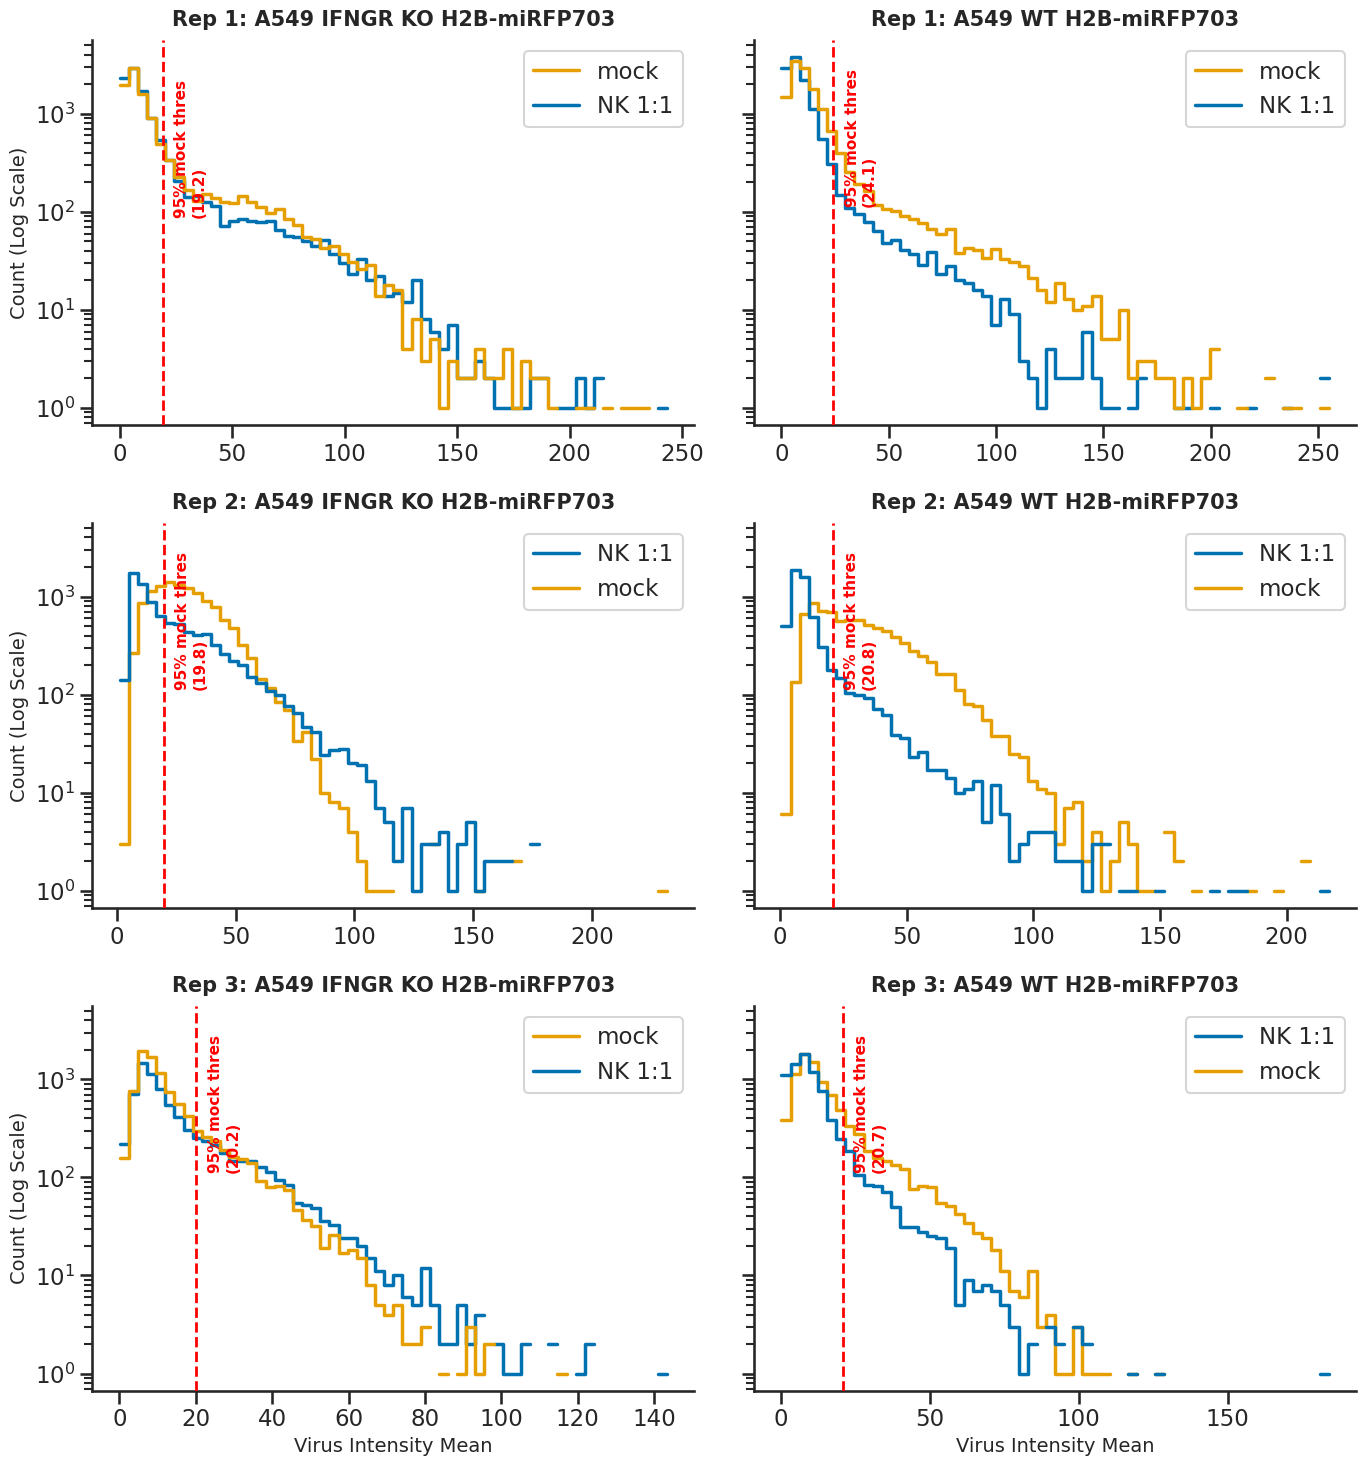

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# 1. Set a clean theme and distinct colors
sns.set_theme(style="ticks", context="talk")
palette = {"mock": "#E69F00", "NK 1:1": "#0072B2"} 

# 2. Create a 3x2 grid of subplots (3 rows for reps, 2 cols for CellType1)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15), sharey=True)

for i, df_rep in enumerate(reps):
    
    # Identify the cell lines (CellType1: e.g., WT vs KO) and sort to ensure consistent columns
    cell_types_1 = sorted(df_rep['CellType1'].unique())
    
    for j, ct1 in enumerate(cell_types_1):
        ax = axes[i, j]
        
        # Isolate data for this specific subplot
        df_sub = df_rep[df_rep['CellType1'] == ct1]
        
        # Separate Infected from Uninfected
        uninfected_mask = df_sub['Virus'].str.contains('mock', case=False, na=False)
        infected_df = df_sub[~uninfected_mask]
        
        # Calculate 95th percentile threshold using wells WITHOUT IAV
        if uninfected_mask.any():
            threshold = df_sub[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
        else:
            threshold = None # Fallback if no mock virus wells exist in a rep
        
        # 3. Plot the step histogram (OUTLINES ONLY)
        sns.histplot(
            data=infected_df,
            x='virus_intensity_mean',
            hue='CellType2',        
            element='step',         
            fill=False,             
            linewidth=2.5,          
            palette=palette,
            log_scale=(False, True),
            bins=60,                
            ax=ax,
            legend=True
        )
        
        # 4. Perform the Kolmogorov-Smirnov Test
        # Separate the two arrays of values for 'mock' and 'NK 1:1'
        dist_mock = infected_df[infected_df['CellType2'].str.contains('mock', case=False, na=False)]['virus_intensity_mean']
        dist_nk = infected_df[infected_df['CellType2'].str.contains('NK', case=False, na=False)]['virus_intensity_mean']
        
        if len(dist_mock) > 0 and len(dist_nk) > 0:
            ks_stat, p_val = ks_2samp(dist_mock, dist_nk)
            
            # Format p-value for clean display
            p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"
            
            # Add a text box with the KS results to the top right of the subplot
            #ax.text(0.95, 0.95, f"K-S Test:\nStat: {ks_stat:.2f}\n{p_text}", 
            #        transform=ax.transAxes, ha='right', va='top', 
             #       fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.5'))

        # 5. Draw the 95th percentile Threshold line
        if threshold is not None:
            ax.axvline(threshold, color='red', linestyle='--', linewidth=2, zorder=5)
            
            # Add a text label for the threshold line (dynamically placed)
            ymin, ymax = ax.get_ylim()
            xmax = ax.get_xlim()[1]
            ax.text(threshold + (xmax * 0.02), ymax * 0.1, 
                    f'95% mock thres\n({threshold:.1f})', 
                    color='red', rotation=90, verticalalignment='center', 
                    fontsize=11, fontweight='bold')

        # 6. Formatting and Titles
        ax.set_title(f"Rep {i+1}: {ct1}", fontsize=15, fontweight='bold', pad=10)
        
        # Only add X labels to the bottom row
        if i == 2:
            ax.set_xlabel('Virus Intensity Mean', fontsize=14)
        else:
            ax.set_xlabel('')
            
        # Only add Y labels to the left column
        if j == 0:
            ax.set_ylabel('Count (Log Scale)', fontsize=14)
        else:
            ax.set_ylabel('')
            
        # Clean up the legend
        if ax.get_legend():
            ax.get_legend().set_title(None) # Removes the "CellType2" title to save space

# Remove top and right borders
sns.despine()
plt.tight_layout()
plt.savefig('/mnt/nas/public/pkaczyns/rsv_histograms_NK_fixed.png')

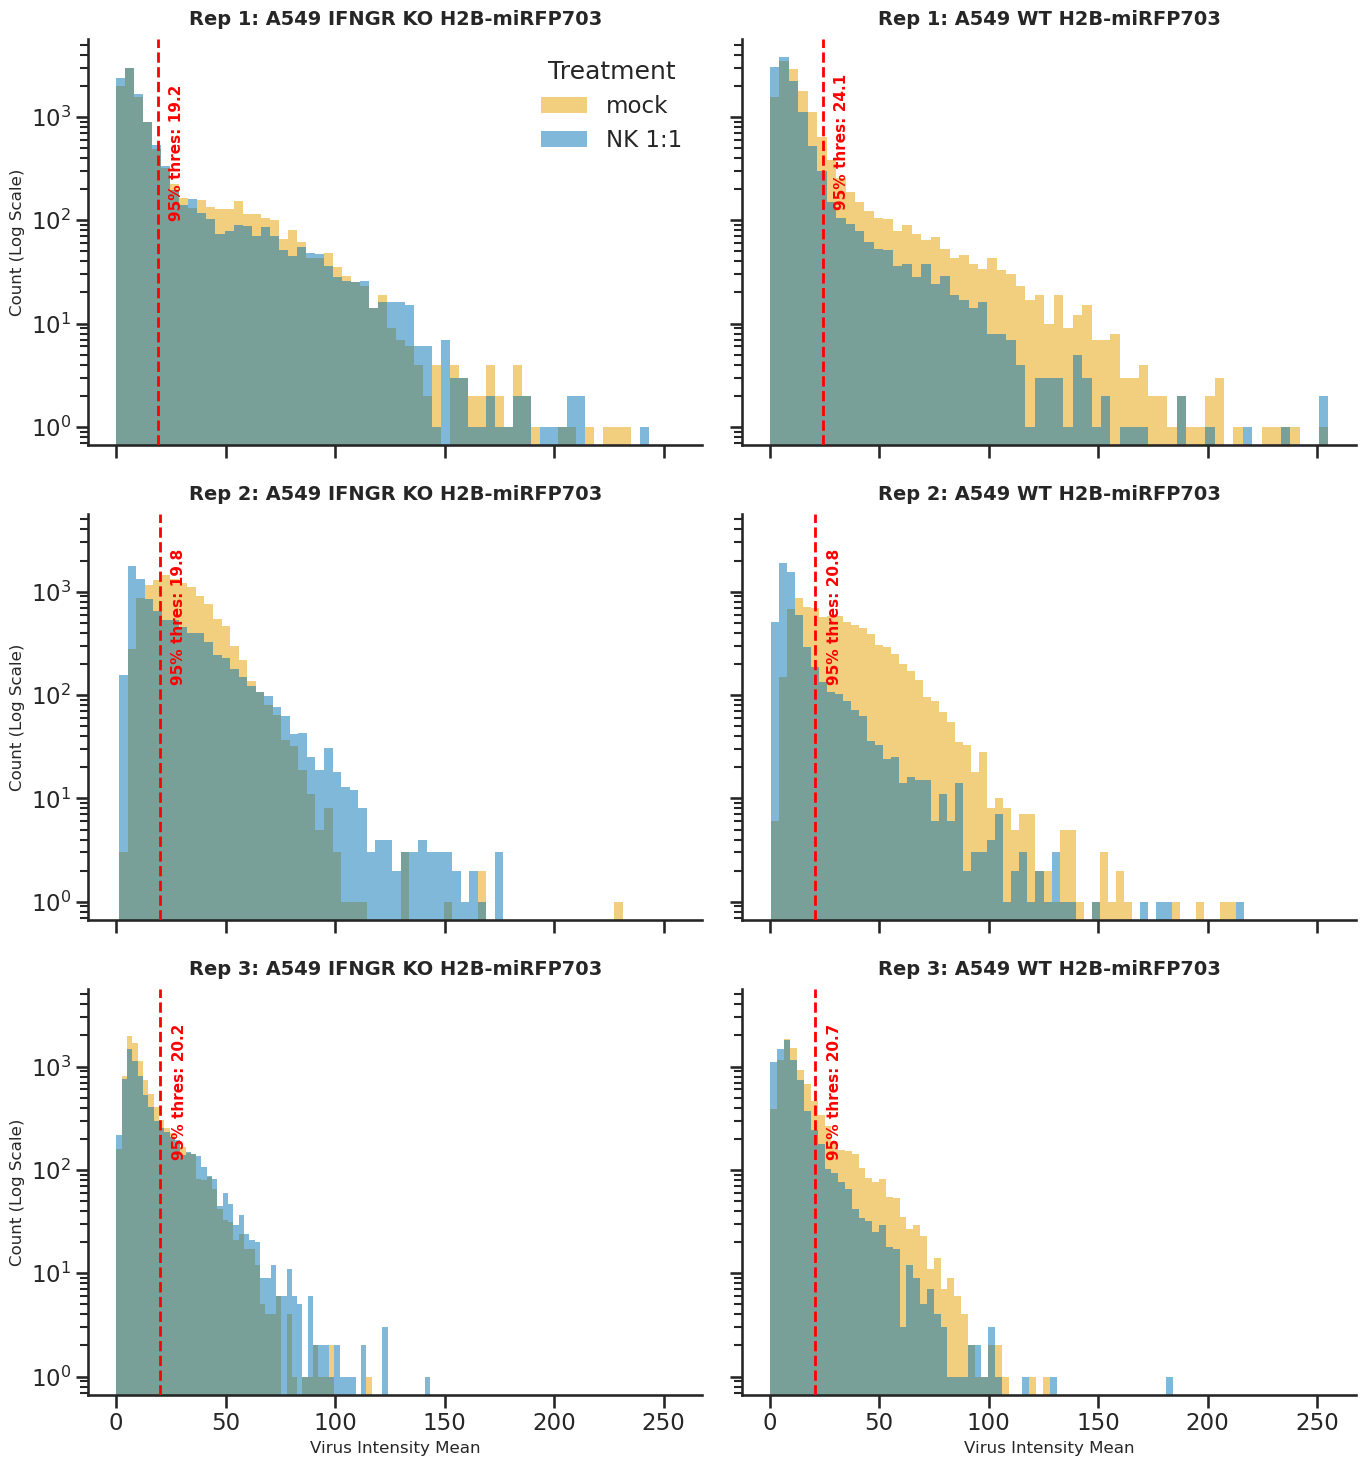

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Set distinct colors
c_mock = "#E69F00"
c_nk = "#0072B2"

# 2. Create a 3x2 grid of subplots using standard Matplotlib
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15), sharey=True, sharex=True)

for i, df_rep in enumerate(reps):
    
    # Identify the cell lines (CellType1: e.g., WT vs KO) and sort to ensure consistent columns
    cell_types_1 = sorted(df_rep['CellType1'].unique())
    
    for j, ct1 in enumerate(cell_types_1):
        ax = axes[i, j]
        
        # Isolate data for this specific subplot
        df_sub = df_rep[df_rep['CellType1'] == ct1]
        
        # Separate Infected from Uninfected
        uninfected_mask = df_sub['Virus'].str.contains('mock', case=False, na=False)
        infected_df = df_sub[~uninfected_mask]
        
        # Calculate 95th percentile threshold using wells WITHOUT IAV
        if uninfected_mask.any():
            threshold = df_sub[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
        else:
            threshold = None 
            
        # 3. Separate the values for plotting
        dist_mock = infected_df[infected_df['CellType2'].str.contains('mock', case=False, na=False)]['virus_intensity_mean']
        dist_nk = infected_df[infected_df['CellType2'].str.contains('NK', case=False, na=False)]['virus_intensity_mean']
        
        # Pre-calculate bins so both distributions align perfectly
        if not infected_df.empty:
            min_val = infected_df['virus_intensity_mean'].min()
            max_val = infected_df['virus_intensity_mean'].max()
            bins = np.linspace(min_val, max_val, 60)
        else:
            bins = 60

        # 4. Pure Matplotlib Histograms (stepfilled + no edge colors)
        if len(dist_mock) > 0:
            ax.hist(dist_mock, bins=bins, color=c_mock, alpha=0.5, log=True, 
                    histtype='stepfilled', edgecolor='none', label='mock')
        
        if len(dist_nk) > 0:
            ax.hist(dist_nk, bins=bins, color=c_nk, alpha=0.5, log=True, 
                    histtype='stepfilled', edgecolor='none', label='NK 1:1')
        
        # 5. Draw the 95th percentile Threshold line
        if threshold is not None:
            ax.axvline(threshold, color='red', linestyle='--', linewidth=2, zorder=5)
            
            # Add a text label for the threshold line
            ymin, ymax = ax.get_ylim()
            xmax = ax.get_xlim()[1]
            ax.text(threshold + (xmax * 0.02), ymax * 0.1, 
                    f'95% thres: {threshold:.1f}', 
                    color='red', rotation=90, verticalalignment='center', 
                    fontsize=11, fontweight='bold')

        # 6. Formatting and Titles
        ax.set_title(f"Rep {i+1}: {ct1}", fontsize=14, fontweight='bold', pad=10)
        
        # Add labels to outer edges only
        if i == 2:
            ax.set_xlabel('Virus Intensity Mean', fontsize=12)
        if j == 0:
            ax.set_ylabel('Count (Log Scale)', fontsize=12)
            
        # Add the legend to the first plot only to avoid clutter
        if i == 0 and j == 0:
            ax.legend(title="Treatment", frameon=False)

# Remove top and right borders (Matplotlib equivalent of sns.despine)
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save the figure FIRST, then display it
plt.savefig('/mnt/nas/public/pkaczyns/rsv_histograms_NK_fixed_full.png', dpi=300, bbox_inches='tight')
plt.show()

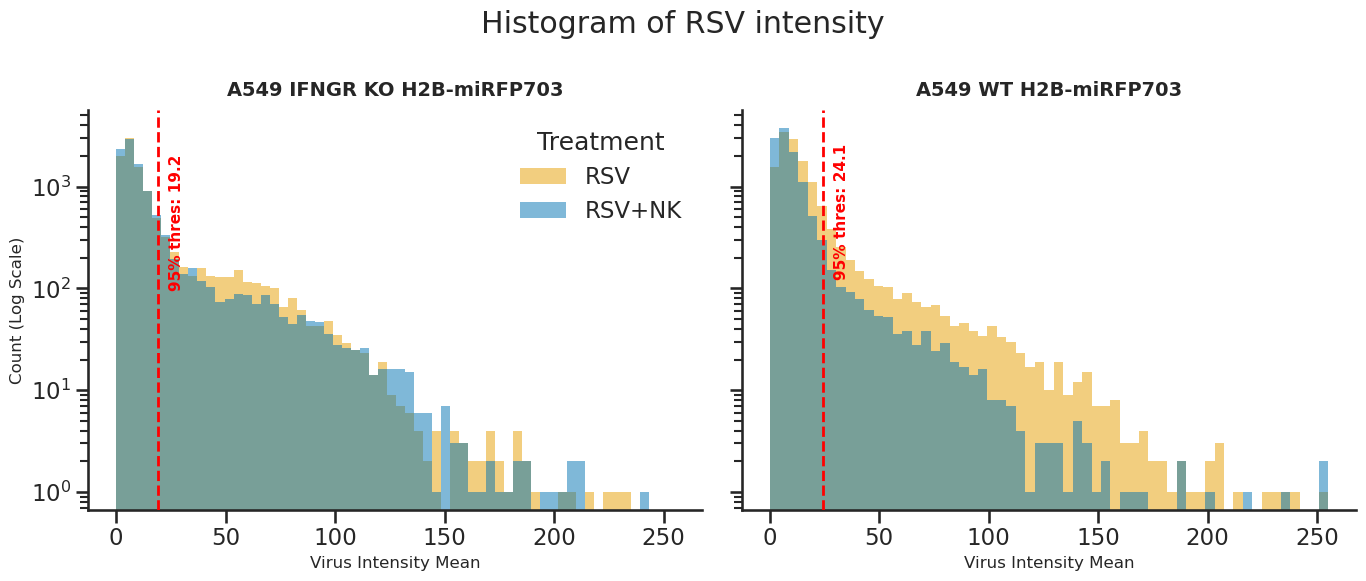

In [91]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True, sharex=True)

for i, df_rep in enumerate([reps[0]]):
    
    # Identify the cell lines (CellType1: e.g., WT vs KO) and sort to ensure consistent columns
    cell_types_1 = sorted(df_rep['CellType1'].unique())
    
    for j, ct1 in enumerate(cell_types_1):
        ax = axes[j]
        
        # Isolate data for this specific subplot
        df_sub = df_rep[df_rep['CellType1'] == ct1]
        
        # Separate Infected from Uninfected
        uninfected_mask = df_sub['Virus'].str.contains('mock', case=False, na=False)
        infected_df = df_sub[~uninfected_mask]
        
        # Calculate 95th percentile threshold using wells WITHOUT IAV
        if uninfected_mask.any():
            threshold = df_sub[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
        else:
            threshold = None 
            
        # 3. Separate the values for plotting
        dist_mock = infected_df[infected_df['CellType2'].str.contains('mock', case=False, na=False)]['virus_intensity_mean']
        dist_nk = infected_df[infected_df['CellType2'].str.contains('NK', case=False, na=False)]['virus_intensity_mean']
        
        # Pre-calculate bins so both distributions align perfectly
        if not infected_df.empty:
            min_val = infected_df['virus_intensity_mean'].min()
            max_val = infected_df['virus_intensity_mean'].max()
            bins = np.linspace(min_val, max_val, 60)
        else:
            bins = 60

        # 4. Pure Matplotlib Histograms (stepfilled + no edge colors)
        if len(dist_mock) > 0:
            ax.hist(dist_mock, bins=bins, color=c_mock, alpha=0.5, log=True, 
                    histtype='stepfilled', edgecolor='none', label='RSV')
        
        if len(dist_nk) > 0:
            ax.hist(dist_nk, bins=bins, color=c_nk, alpha=0.5, log=True, 
                    histtype='stepfilled', edgecolor='none', label='RSV+NK')
        
        # 5. Draw the 95th percentile Threshold line
        if threshold is not None:
            ax.axvline(threshold, color='red', linestyle='--', linewidth=2, zorder=5)
            
            # Add a text label for the threshold line
            ymin, ymax = ax.get_ylim()
            xmax = ax.get_xlim()[1]
            ax.text(threshold + (xmax * 0.02), ymax * 0.1, 
                    f'95% thres: {threshold:.1f}', 
                    color='red', rotation=90, verticalalignment='center', 
                    fontsize=11, fontweight='bold')

        # 6. Formatting and Titles
        ax.set_title(f"{ct1}", fontsize=14, fontweight='bold', pad=10)
        
        # Add labels to outer edges only
        ax.set_xlabel('Virus Intensity Mean', fontsize=12)
        if j == 0:
            ax.set_ylabel('Count (Log Scale)', fontsize=12)
            
        # Add the legend to the first plot only to avoid clutter
        if i == 0 and j == 0:
            ax.legend(title="Treatment", frameon=False)
        

# Remove top and right borders (Matplotlib equivalent of sns.despine)
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Histogram of RSV intensity')
plt.tight_layout()

# Save the figure FIRST, then display it
plt.savefig('/mnt/nas/public/pkaczyns/rsv_histograms_NK_fixed_full_rep1.png', dpi=300, bbox_inches='tight')

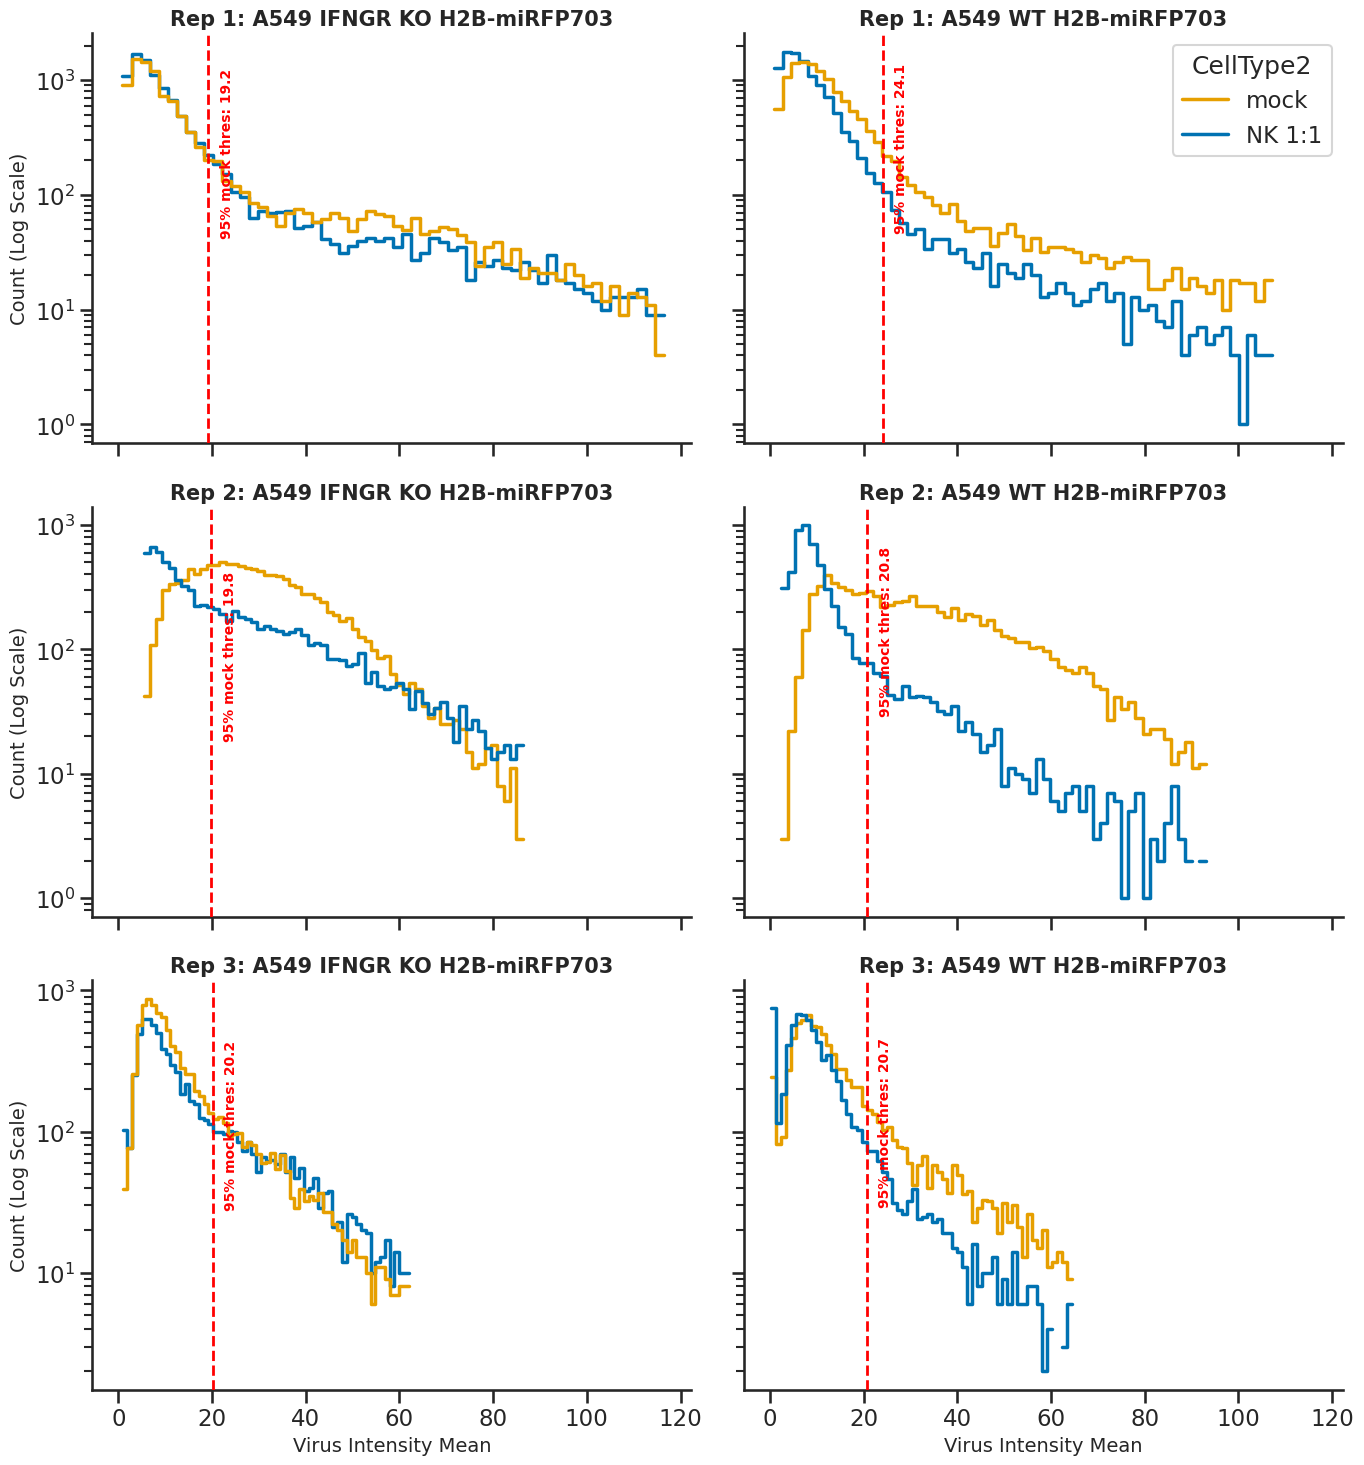

--- Statistical Testing Across 3 Repetitions ---
Test: Paired t-test on Replicate Medians (N=3)

Cell Line: A549 IFNGR KO H2B-miRFP703
  Mock Median across reps: 15.6
  NK Median across reps:   12.5
  Average Reduction:       19.5%
  Paired t-test p-value:   0.4173

Cell Line: A549 WT H2B-miRFP703
  Mock Median across reps: 17.2
  NK Median across reps:   8.2
  Average Reduction:       52.2%
  Paired t-test p-value:   0.2608



In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
import numpy as np

# 1. Helper function to remove outliers safely
def remove_outliers(df, column='virus_intensity_mean'):
    """Removes top 1% and bottom 1% to drop technical artifacts without deleting the biological right-tail."""
    p01 = df[column].quantile(0.01)
    p99 = df[column].quantile(0.99)
    return df[(df[column] >= p01) & (df[column] <= p99)].copy()

# Set up theme and colors
sns.set_theme(style="ticks", context="talk")
palette = {"mock": "#E69F00", "NK 1:1": "#0072B2"} 

# Identify CellType1 from the first replicate
cell_types_1 = sorted(reps[0]['CellType1'].unique())

# Set up 3x2 Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15), sharey='row', sharex=True)

# Dictionaries to store medians for our statistical test later
# Structure: { 'A549 WT': {'mock': [rep1, rep2, rep3], 'NK 1:1': [rep1, rep2, rep3]} }
stats_data = {ct: {'mock': [], 'NK 1:1':[]} for ct in cell_types_1}

for i, df_rep in enumerate(reps):
    for j, ct1 in enumerate(cell_types_1):
        ax = axes[i, j]
        
        # Isolate data for this subplot
        df_sub = df_rep[df_rep['CellType1'] == ct1].copy()
        
        # Identify uninfected wells to calculate threshold
        uninfected_mask = df_sub['Virus'].str.contains('mock', case=False, na=False)
        if uninfected_mask.any():
            threshold = df_sub[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
        else:
            threshold = None
            
        # Filter to keep ONLY IAV-infected wells, then REMOVE OUTLIERS
        infected_df = df_sub[~uninfected_mask]
        infected_clean = remove_outliers(infected_df, 'virus_intensity_mean')
        
        # Extract medians for the statistical test across reps
        med_mock = infected_clean[infected_clean['CellType2'].str.contains('mock', case=False, na=False)]['virus_intensity_mean'].median()
        med_nk = infected_clean[infected_clean['CellType2'].str.contains('NK', case=False, na=False)]['virus_intensity_mean'].median()
        
        stats_data[ct1]['mock'].append(med_mock)
        stats_data[ct1]['NK 1:1'].append(med_nk)

        # Plot Step Histograms (Outlines Only)
        sns.histplot(
            data=infected_clean,
            x='virus_intensity_mean',
            hue='CellType2',        
            element='step',         
            fill=False,             
            linewidth=2.5,          
            palette=palette,
            log_scale=(False, True),
            bins=60,                
            ax=ax,
            legend=(i == 0 and j == 1) # Only show legend once to save space
        )

        # Draw 95% Threshold
        if threshold is not None:
            ax.axvline(threshold, color='red', linestyle='--', linewidth=2, zorder=5)
            # Threshold text
            ymin, ymax = ax.get_ylim()
            xmax = ax.get_xlim()[1]
            ax.text(threshold + (xmax * 0.02), ymax * 0.1, 
                    f'95% mock thres: {threshold:.1f}', 
                    color='red', rotation=90, verticalalignment='center', 
                    fontsize=10, fontweight='bold')

        # Formatting
        ax.set_title(f"Rep {i+1}: {ct1}", fontsize=15, fontweight='bold')
        if i == 2:
            ax.set_xlabel('Virus Intensity Mean', fontsize=14)
        else:
            ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel('Count (Log Scale)', fontsize=14)
        else:
            ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================
# 2. STATISTICAL TESTING ACROSS REPETITIONS
# ==========================================
print("--- Statistical Testing Across 3 Repetitions ---")
print("Test: Paired t-test on Replicate Medians (N=3)\n")

for ct1 in cell_types_1:
    mock_vals = stats_data[ct1]['mock']
    nk_vals = stats_data[ct1]['NK 1:1']
    
    # Paired t-test
    t_stat, p_val = ttest_rel(mock_vals, nk_vals)
    
    # Calculate average drop
    mean_mock = np.mean(mock_vals)
    mean_nk = np.mean(nk_vals)
    pct_reduction = ((mean_mock - mean_nk) / mean_mock) * 100
    
    print(f"Cell Line: {ct1}")
    print(f"  Mock Median across reps: {mean_mock:.1f}")
    print(f"  NK Median across reps:   {mean_nk:.1f}")
    print(f"  Average Reduction:       {pct_reduction:.1f}%")
    print(f"  Paired t-test p-value:   {p_val:.4f}\n")

In [ ]:

extract_wells_info('/mnt/data/2025-02-08-namirine-TBA/fixed')

,,,well,Virus,CellType1,CellType2,experiment
0,3,2,0302,mock,A549 WT H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
1,3,3,0303,RSV 0.1 NB6,A549 WT H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
2,3,4,0304,RSV 0.1 NB6,A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
3,3,6,0306,mock,A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
4,4,5,0405,mock,A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
5,4,7,0407,RSV 0.1 NB6,A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2025-02-08-namirine-TBA/fixed
6,4,9,0409,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed
7,5,8,0508,RSV 0.1 NB6,A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2025-02-08-namirine-TBA/fixed


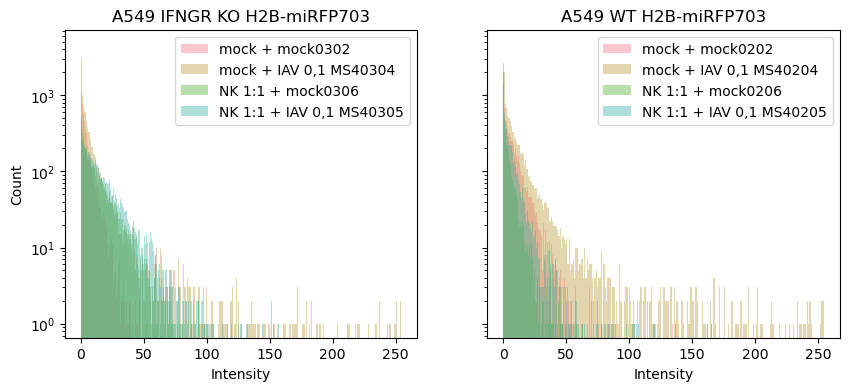

In [56]:
def plot_histograms(df, color_map):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Create consistent color mapping for CellType2 (NK/non-NK)
    celltype2_unique = list(df[['CellType2', 'Virus']].value_counts().index) #df[['CellType2', 'Virus_name']].unique() #_name
    #color_map = {ct2: colors[i % len(colors)] for i, ct2 in enumerate(celltype2_unique)}

    # Group by Virus and CellType1 to identify subplot position
    viruses = ['IAV', 'RSV']  # Adjust if more viruses are expected
    celltypes = sorted(df['CellType1'].unique())

    # Plotting
    #for row_idx, virus in enumerate(viruses):
    for col_idx, celltype in enumerate(celltypes):
        ax = axs[col_idx]
        subset = df[(df['CellType1'] == celltype)] # (df['Virus_name'] == virus) & 
        
        for ct2 in celltype2_unique:
            group = subset[(subset['CellType2'] == ct2[0])&(subset['Virus'] == ct2[1])]

            if not group.empty:
                ax.hist(group['virus_intensity_mean'], bins=250, alpha=0.4, label=ct2[0]+' + '+ct2[1]+group['well'].iloc[0], color=color_map[ct2])# density=True, 
        #ax.set_yscale('log')
        ax.set_title(f"{celltype}")
        #if row_idx == 1:
        ax.set_xlabel('Intensity')
        ax.set_yscale('log')
        if col_idx == 0:
            ax.set_ylabel('Count')
        if col_idx == 4:
            ax.legend(loc='upper right')
        #threshold = subset['threshold'].iloc[0]
        #ax.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.2f}')
        ax.legend()
    #plt.suptitle(exp_name)
    #plt.tight_layout()
    plt.show()#savefig(exp_name+)


colors = sns.color_palette('husl')#['red', 'blue', 'green', 'orange']#
color_map = {ct2: colors[i % len(colors)] for i, ct2 in enumerate(list(exp[['CellType2', 'Virus']].value_counts().index))}

cols = exp.dropna(axis=1).columns
#group = group[group['Virus']!='mock']
plot_histograms(exp.rename({'Compound': 'Virus', 'Cell Type 2': 'CellType2', 'Cell Type': 'CellType1'}, axis=1), color_map)

In [13]:
df_summary

,CellType1,CellType2,is_infected,percent_infected,Replicate
0,A549 IFNGR KO H2B-miRFP703,NK 1:1,0.132844,13.284372,Rep_1
1,A549 IFNGR KO H2B-miRFP703,mock,0.113342,11.334179,Rep_1
2,A549 WT H2B-miRFP703,NK 1:1,0.053630,5.363006,Rep_1
3,A549 WT H2B-miRFP703,mock,0.154730,15.472979,Rep_1
4,A549 IFNGR KO H2B-miRFP703,NK 1:1,0.300226,30.022603,Rep_2
5,A549 IFNGR KO H2B-miRFP703,mock,0.186849,18.684872,Rep_2
6,A549 WT H2B-miRFP703,NK 1:1,0.178817,17.881720,Rep_2
7,A549 WT H2B-miRFP703,mock,0.199215,19.921507,Rep_2
8,A549 IFNGR KO H2B-miRFP703,NK 1:1,0.237517,23.751704,Rep_3
9,A549 IFNGR KO H2B-miRFP703,mock,0.211475,21.147489,Rep_3


/tmp/ipykernel_26443/1322083357.py:63: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


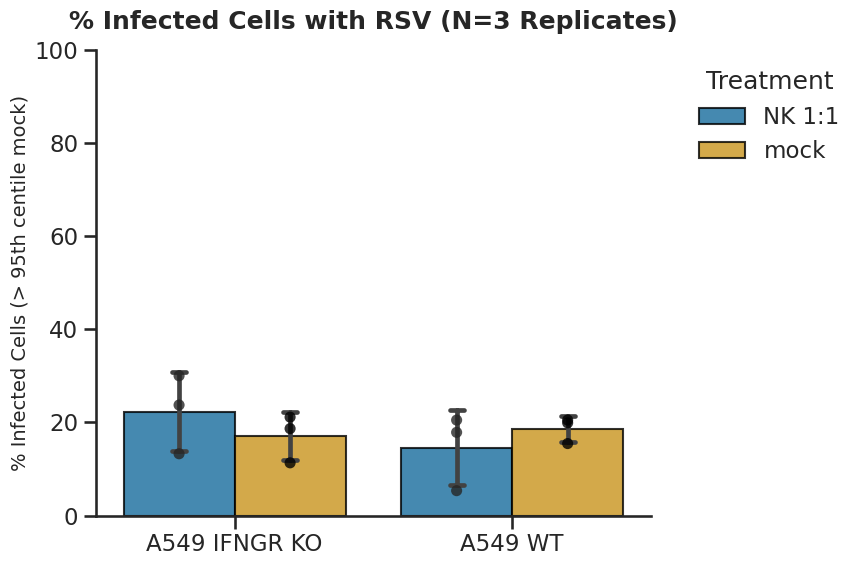


--- Summary Statistics (% Infected) ---
                          mean   std
CellType1     CellType2             
A549 IFNGR KO NK 1:1     22.35  8.46
              mock       17.06  5.11
A549 WT       NK 1:1     14.59  8.10
              mock       18.64  2.76


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PROCESS DATA TO CALCULATE % INFECTED
summary_data =[]

for i, df_rep in enumerate(reps):
    # Identify uninfected wells to calculate the GLOBAL threshold for this replicate
    # We use all 'mock' virus wells, "not divided to celltype" as requested
    uninfected_mask = df_rep['Virus'].str.contains('mock', case=False, na=False)
    
    if not uninfected_mask.any():
        print(f"Warning: No uninfected wells in Replicate {i+1}. Skipping.")
        continue
        
    threshold = df_rep[uninfected_mask]['virus_intensity_mean'].quantile(0.95)
    
    # Filter to keep ONLY the IAV-infected wells
    infected_df = df_rep[~uninfected_mask].copy()
    
    # Determine which cells are "Infected" (intensity > threshold)
    infected_df['is_infected'] = infected_df['virus_intensity_mean'] > threshold
    
    # Calculate the percentage of infected cells for each condition
    # Grouping by CellType1 (WT/KO) and CellType2 (NK/mock)
    # The .mean() of a boolean column gives the fraction of True values (e.g., 0.85 = 85%)
    grouped = infected_df.groupby(['CellType1', 'CellType2'])['is_infected'].mean().reset_index()
    grouped['percent_infected'] = grouped['is_infected'] * 100  # Convert to percentage
    
    # Label which replicate this came from
    grouped['Replicate'] = f"Rep_{i+1}"
    
    summary_data.append(grouped)

# Combine into a single clean DataFrame containing just our N=3 summary points
df_summary = pd.concat(summary_data, ignore_index=True)
df_summary['CellType1'] = df_summary['CellType1'].map({'A549 IFNGR KO H2B-miRFP703': 'A549 IFNGR KO', 'A549 WT H2B-miRFP703': 'A549 WT'})


# 2. PLOT THE BARPLOT WITH OVERLAYS
sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(9, 6))

# Define our colors
palette = {"mock": "#E69F00", "NK 1:1": "#0072B2"} 

# Create the Bar Plot (Mean of the 3 replicates + Standard Deviation)
sns.barplot(
    data=df_summary,
    x='CellType1',
    y='percent_infected',
    hue='CellType2',
    palette=palette,
    edgecolor='black',   # Adds a crisp black border to the bars
    linewidth=1.5,
    errorbar='sd',       # 'sd' = Standard Deviation across the 3 replicates
    capsize=0.1,         # Adds caps to the ends of the error bars
    alpha=0.8
)

# Overlay the individual replicate points (N=3) as dots
sns.stripplot(
    data=df_summary,
    x='CellType1',
    y='percent_infected',
    hue='CellType2',
    dodge=True,          # Aligns the dots perfectly over their respective bars
    color='black',       # Black dots
    alpha=0.8,
    size=8,              # Slightly larger dots for visibility
    jitter=False,        # Keeps the 3 dots in a straight vertical line
    legend=False         # Prevents duplicating the legend
)

# 3. FORMATTING
plt.title('% Infected Cells with RSV (N=3 Replicates)', fontweight='bold', pad=15)
plt.ylabel('% Infected Cells (> 95th centile mock)', fontsize=14)
plt.xlabel('')

# Set Y-axis to start at 0, and optionally cap at 100 if it makes sense for your data
plt.ylim(0, max(df_summary['percent_infected'].max() + 15, 100))

# Clean up legend and place it outside the plot
plt.legend(title='Treatment', frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right borders
sns.despine()

plt.tight_layout()

# Save and Show
#plt.savefig('/mnt/nas/public/pkaczyns/rsv_percent_infected_barplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the summary stats to the console so you can see the exact numbers
print("\n--- Summary Statistics (% Infected) ---")
display_df = df_summary.groupby(['CellType1', 'CellType2'])['percent_infected'].agg(['mean', 'std']).round(2)
print(display_df)

In [36]:
df_summary = df_summary[df_summary['Replicate']=='Rep_1']

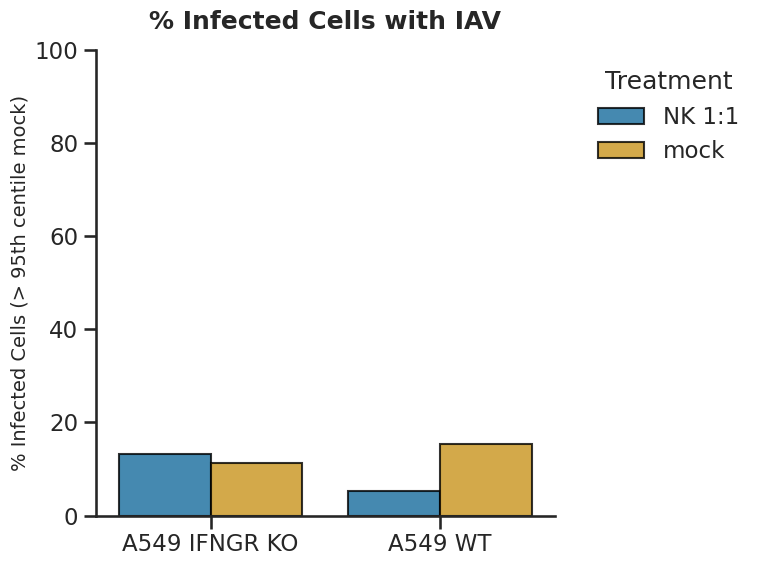


--- Single Replicate Percentages ---
       CellType1 CellType2  percent_infected
0  A549 IFNGR KO    NK 1:1             13.28
1  A549 IFNGR KO      mock             11.33
2        A549 WT    NK 1:1              5.36
3        A549 WT      mock             15.47


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme
sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(8, 6))

# Define our colors for consistency
palette = {"mock": "#E69F00", "NK 1:1": "#0072B2"} 

# Create the Bar Plot
sns.barplot(
    data=df_summary,
    x='CellType1',
    y='percent_infected',
    hue='CellType2',
    palette=palette,
    edgecolor='black',   # Adds a crisp black border to the bars
    linewidth=1.5,
    errorbar=None,       # IMPORTANT: Turn off error bars since N=1
    alpha=0.8
)

# FORMATTING
plt.title('% Infected Cells with IAV', fontweight='bold', pad=15)
plt.ylabel('% Infected Cells (> 95th centile mock)', fontsize=14)
plt.xlabel('')

# Set Y-axis to start at 0, and give a little headroom above the tallest bar
max_val = df_summary['percent_infected'].max()
plt.ylim(0, max(max_val + 15, 100)) # Caps at 100 if appropriate, or higher if needed

# Clean up legend and place it outside the plot
plt.legend(title='Treatment', frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right borders for a modern look
sns.despine()

plt.tight_layout()

# Save and Show
plt.savefig('/mnt/nas/public/pkaczyns/iav_percent_infected_rep1.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the values to the console
print("\n--- Single Replicate Percentages ---")
print(df_summary[['CellType1', 'CellType2', 'percent_infected']].round(2))

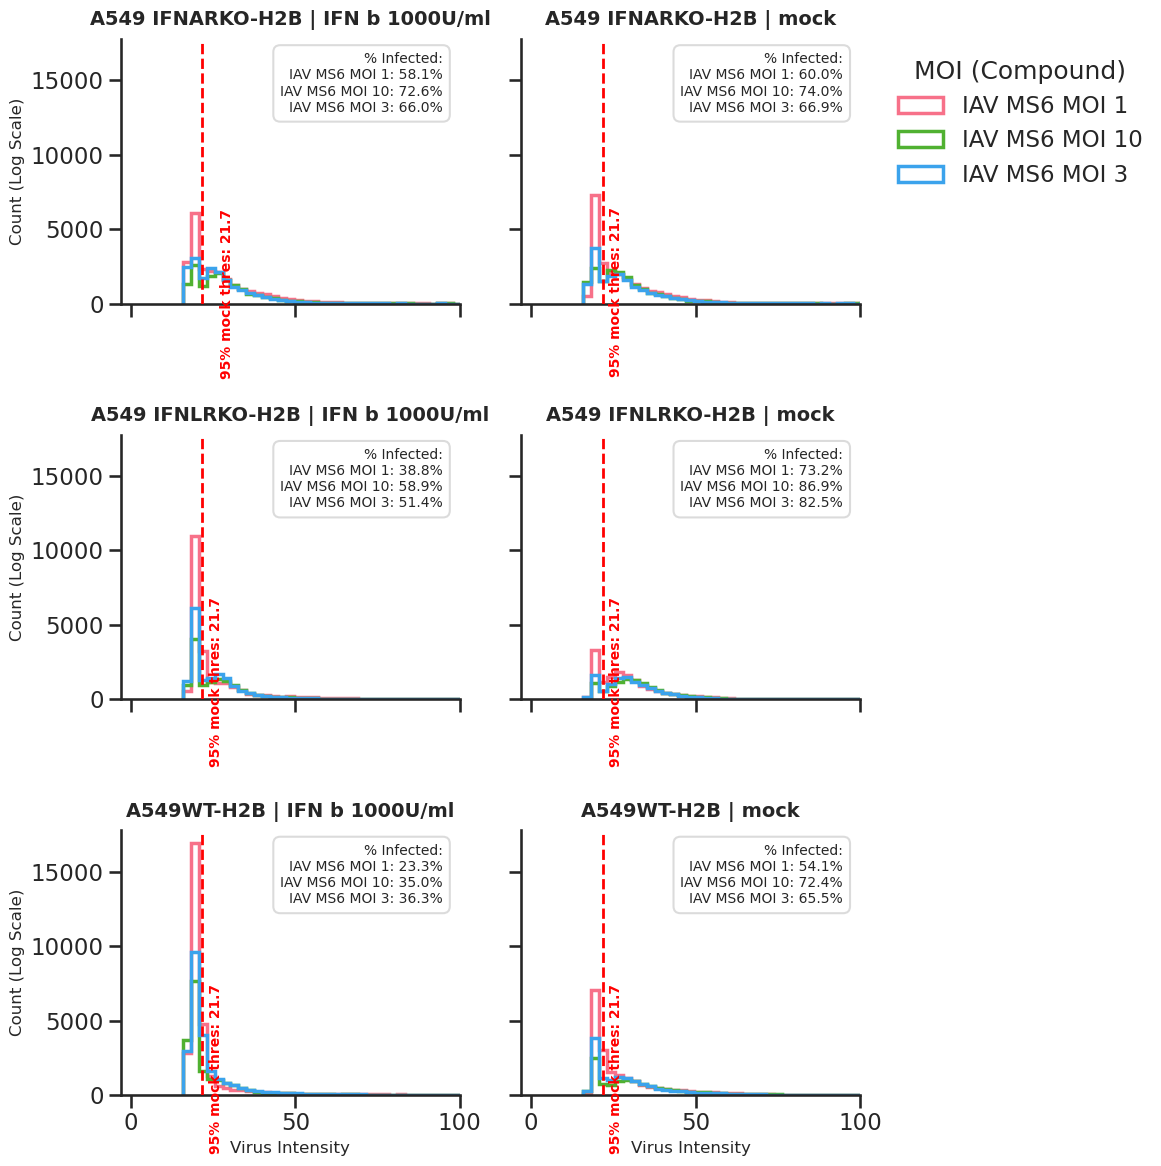

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = reps[0]
# --- CONFIGURATION ---
intensity_col = 'virus_intensity_mean'  # Change to '_median' if needed based on your df

# 1. CALCULATE GLOBAL THRESHOLD
# Find all wells without the virus (assuming 'Compound' contains 'mock')
mock_mask = df['Compound'].str.contains('mock', case=False, na=False)

if mock_mask.any():
    # One threshold calculated from ALL mock wells pooled together
    global_threshold = df[mock_mask][intensity_col].quantile(0.95)
else:
    global_threshold = None
    print("Warning: No mock wells found to calculate threshold.")

# Filter out the mock wells so we only plot the infected MOIs
infected_df = df[~mock_mask].copy()

# 2. IDENTIFY GRID DIMENSIONS & MOI CATEGORIES
cell_types = sorted(infected_df['Cell Type'].dropna().unique())
compounds_2 = sorted(infected_df['compound 2'].dropna().unique())
mois = sorted(infected_df['Compound'].dropna().unique())

# Assign distinct colors to each MOI dynamically
colors = sns.color_palette("husl", len(mois))
moi_colors = dict(zip(mois, colors))

# 3. CREATE SUBPLOTS
# Rows = Cell Types, Columns = Compound 2
fig, axes = plt.subplots(nrows=len(cell_types), ncols=len(compounds_2), 
                         figsize=(6 * len(compounds_2), 4 * len(cell_types)), 
                         sharey=True, sharex=True, squeeze=False)

# Pre-calculate global bins so all histograms align perfectly on the X-axis
if not infected_df.empty:
    min_val = infected_df[intensity_col].min()
    max_val = infected_df[intensity_col].max()
    bins = np.linspace(min_val, max_val, 100)
else:
    bins = 60

# 4. PLOT EACH COMBINATION
for i, ct in enumerate(cell_types):
    for j, c2 in enumerate(compounds_2):
        ax = axes[i, j]
        
        # Isolate data for this specific Cell Type and Compound 2 combination
        subset = infected_df[(infected_df['Cell Type'] == ct) & (infected_df['compound 2'] == c2)]
        
        if subset.empty:
            ax.set_title(f"{ct} | {c2}\n(No Data)", fontsize=12)
            continue
            
        # List to store the text lines for % infected
        stats_text = ["% Infected:"]
            
        # Plot each MOI histogram and calculate proportion
        for moi in mois:
            moi_data = subset[subset['Compound'] == moi][intensity_col]
            
            if len(moi_data) > 0:
                # Plot outline
                ax.hist(moi_data, bins=bins, color=moi_colors[moi], alpha=1.0, 
                        histtype='step', linewidth=2.5, label=str(moi))
                
                # Calculate proportion above threshold
                if global_threshold is not None:
                    pct_infected = (moi_data > global_threshold).mean() * 100
                    stats_text.append(f"{moi}: {pct_infected:.1f}%")
        
        # Add the stats text box to the top right corner of the subplot
        if global_threshold is not None and len(stats_text) > 1:
            ax.text(0.95, 0.95, "\n".join(stats_text), 
                    transform=ax.transAxes, ha='right', va='top', 
                    fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.5'))
        
        # Draw the Global Threshold line
        if global_threshold is not None:
            ax.axvline(global_threshold, color='red', linestyle='--', linewidth=2, zorder=5)
            
            # Add text label for threshold at the bottom
            ymin, ymax = ax.get_ylim()
            xmax = ax.get_xlim()[1]
            ax.text(global_threshold + (xmax * 0.02), ymax * 0.1, 
                    f'95% mock thres: {global_threshold:.1f}', 
                    color='red', rotation=90, verticalalignment='center', 
                    fontsize=10, fontweight='bold')

        # Formatting & Titles
        ax.set_title(f"{ct} | {c2}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlim([-3, 100])
        # Add labels to outer edges only
        if i == len(cell_types) - 1:
            ax.set_xlabel('Virus Intensity', fontsize=12)
        if j == 0:
            ax.set_ylabel('Count (Log Scale)', fontsize=12)
            
        # Add legend outside the top-right plot
        if i == 0 and j == len(compounds_2) - 1:
            ax.legend(title="MOI (Compound)", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right borders
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save and Show
#plt.savefig('/mnt/nas/public/pkaczyns/iav_histograms_MOI_outlines_with_stats.png', dpi=300, bbox_inches='tight')
plt.show()